# 第018讲 概率事件与条件信息

一台检测器的检出率是80%，为什么报警后的缺陷概率只有约13.9%？从一张原创合成列联表开始，分别用计数、Bayes公式与模拟回答。

直接先修：第2、8讲。集合、条件概率和有限加权平均见正文。本实验仅用小CPU合成数据，不提供真实设备、医疗或因果判断。

先完成实验指南的纸笔预测，再重启内核并顺序运行全部。本Notebook导入同目录experiment.py；核心计算没有另一套实现。

## 设置与可复现范围

NumPy负责离线抽样，Matplotlib负责画图。PNG通过IPython.display真实写进输出，而不是只引用磁盘图。全部数据从脚本所在目录读取，结果写入outputs。固定答案来自有限合成模型；重复模拟范围只是估计比例的经验波动，不是置信区间。

In [1]:
from pathlib import Path
from io import BytesIO
import sys
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Image, display
import experiment as e
font = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if font.exists():
    font_manager.fontManager.addfont(str(font))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(font)).get_name()
plt.rcParams.update({"font.size":11,"axes.unicode_minus":False,
                     "axes.spines.top":False,"axes.spines.right":False})
BLUE, TEAL, ORANGE, RED = "#2869A6", "#158378", "#D2822F", "#BE4355"
def show_png(fig):
    buffer = BytesIO()
    fig.savefig(buffer,format="png",dpi=135,bbox_inches="tight",pad_inches=.2)
    plt.close(fig)
    display(Image(data=buffer.getvalue()))
print({"Python":sys.version.split()[0],"NumPy":np.__version__,"Matplotlib":matplotlib.__version__})
print("module:",Path(e.__file__).name,"tolerance:",e.ATOL)

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8'}
module: experiment.py tolerance: 1e-12


## 1 先明确行列与分母

预测主表的行合计100、9900，列合计575、9425。这里是完整合成总体；均匀抽一台时，其比例为精确概率。后面的随机抽样将产生另一张经验表。

In [2]:
table, groups, triples = e.load_data()
fixed = e.summarize_table(table)
print("shape:",table.shape,"rows: defect / clean; columns: alarm / no_alarm")
print(table)
print("row totals:",table.sum(axis=1),"column totals:",table.sum(axis=0))
for key in ["p_defect","p_alarm","p_alarm_given_defect","p_alarm_given_clean",
            "p_defect_given_alarm","p_defect_given_no_alarm"]:
    print(key, "=",fixed[key])
e.require(fixed["p_defect_given_alarm"] == 16/115,"主表后验核对失败")

shape: (2, 2) rows: defect / clean; columns: alarm / no_alarm
[[  80   20]
 [ 495 9405]]
row totals: [ 100 9900] column totals: [ 575 9425]
p_defect = 0.01
p_alarm = 0.0575
p_alarm_given_defect = 0.8
p_alarm_given_clean = 0.05
p_defect_given_alarm = 0.1391304347826087
p_defect_given_no_alarm = 0.002122015915119363


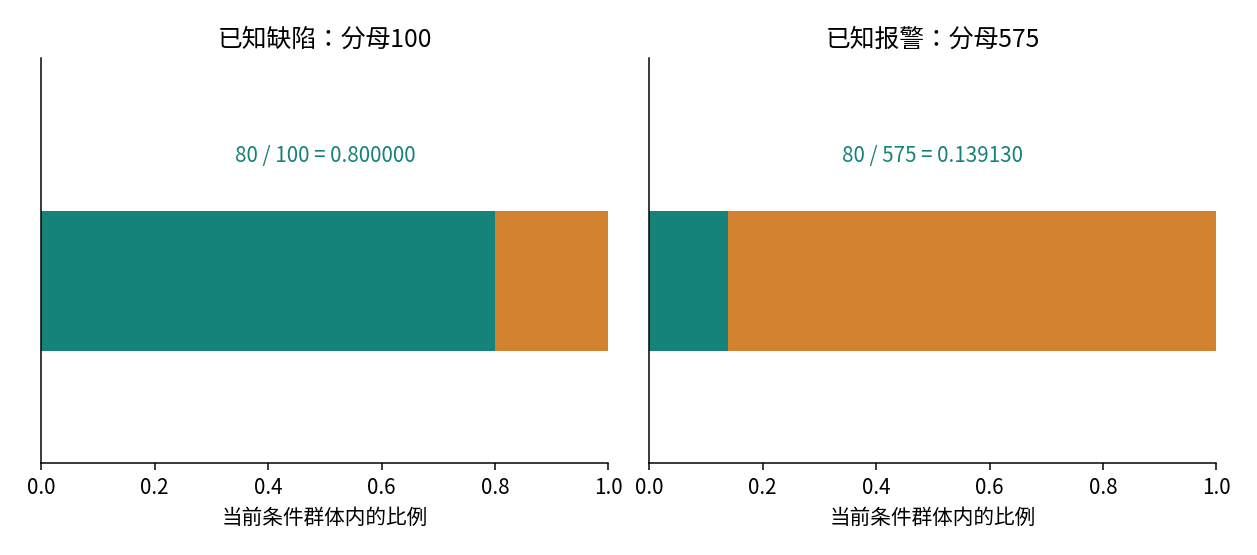

In [3]:
fig, axes = plt.subplots(1,2,figsize=(9,3.8),layout="constrained")
for ax, counts, title in zip(axes,[[int(table[0,0]),int(table[0,1])],
                                 [int(table[0,0]),int(table[1,0])]],
                           ["已知缺陷：分母100","已知报警：分母575"]):
    total=sum(counts)
    ax.barh([0],[counts[0]/total],color=TEAL,height=.5)
    ax.barh([0],[counts[1]/total],left=counts[0]/total,color=ORANGE,height=.5)
    ax.text(.5,.43,f"{counts[0]} / {total} = {counts[0]/total:.6f}",ha="center",color=TEAL)
    ax.set(xlim=(0,1),ylim=(-.65,.8),yticks=[],xlabel="当前条件群体内的比例",title=title)
show_png(fig)

## 2 联合质量与后验

先验对应[缺陷,合格]，似然对应[缺陷下报警,合格下报警]。请先算两个权重0.008、0.0495，再把它们相加。只除以缺陷先验会算回检出率。

In [4]:
update = e.bayes([.01,.99],[.8,.05])
print(update)
e.require(abs(update["evidence"]-23/400) < e.ATOL,"证据总量错误")
e.require(abs(update["posterior"][0]-16/115) < e.ATOL,"后验错误")
print("Fraction独立精确核验:",e.fraction_checks()["posterior_alarm"])
print("交换标签与两向量:",e.bayes([.99,.01],[.05,.8])["posterior"])

{'posterior': [0.1391304347826087, 0.8608695652173913], 'evidence': 0.0575, 'raw_evidence': 0.0575, 'evidence_roundoff_adjustment': 0.0, 'weights': [0.008, 0.0495]}
Fraction独立精确核验: 16/115
交换标签与两向量: [0.8608695652173913, 0.1391304347826087]


## 3 改变目标总体的基准率

检测器机制保持s=0.8、f=0.05。图中曲线不是训练拟合；每个点直接由概率公式得到。横轴为对数尺度，特意展开稀少缺陷区域。

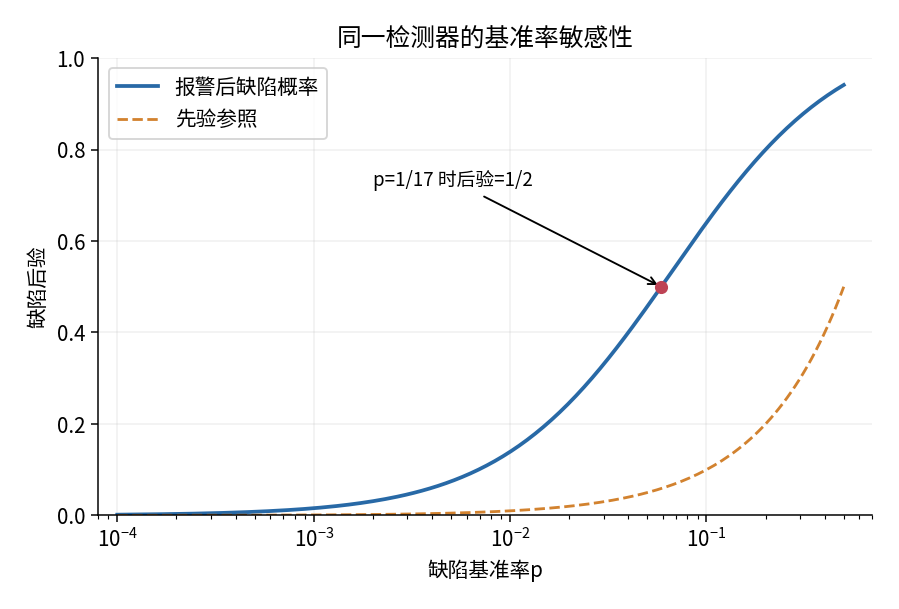

0.001 0.015763546798029555
0.01 0.1391304347826087
0.05 0.4571428571428572
0.1 0.64
0.5 0.9411764705882353
无区分信息: [0.01, 0.99]


In [5]:
priors = np.geomspace(.0001,.5,180)
posterior = [e.bayes([float(p),float(1-p)],[.8,.05])["posterior"][0] for p in priors]
fig, ax = plt.subplots(figsize=(7.4,4.4))
ax.plot(priors,posterior,color=BLUE,lw=2,label="报警后缺陷概率")
ax.plot(priors,priors,"--",color=ORANGE,label="先验参照")
threshold = 1/17
ax.scatter([threshold],[.5],color=RED,zorder=4)
ax.annotate("p=1/17 时后验=1/2",(threshold,.5),xytext=(.002,.72),
            arrowprops={"arrowstyle":"->"},fontsize=10)
ax.set(xscale="log",xlim=(.00008,.7),ylim=(0,1),xlabel="缺陷基准率p",ylabel="缺陷后验",title="同一检测器的基准率敏感性")
ax.legend(loc="upper left");ax.grid(alpha=.2);show_png(fig)
for p in [.001,.01,.05,.1,.5]:
    print(p,e.bayes([p,1-p],[.8,.05])["posterior"][0])
print("无区分信息:",e.bayes([.01,.99],[.2,.2])["posterior"])

## 4 两次报警是否是两条证据

仅在两个通道给定D、给定D的补集后分别独立时，似然可以各自平方。复制同一报警在旧信息下已必然成立，其新增似然是[1,1]。

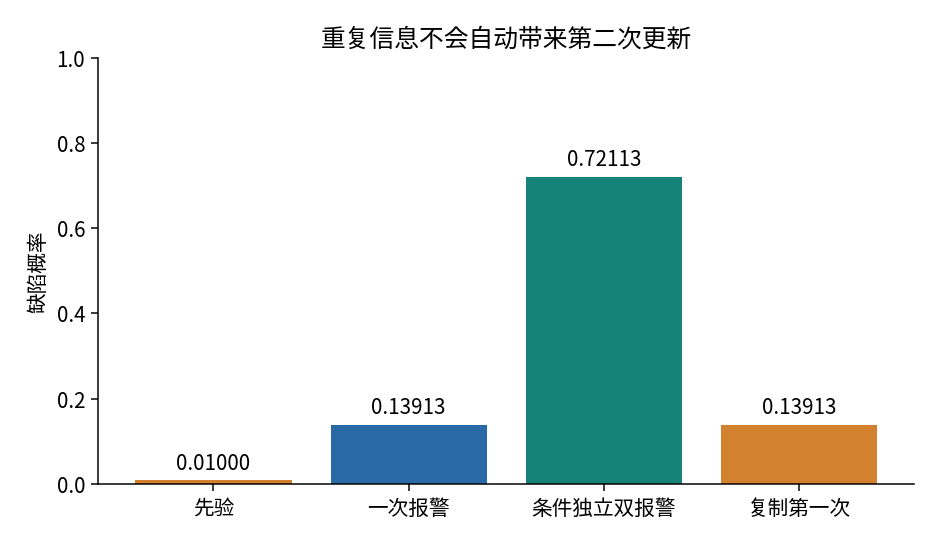

In [6]:
independent_second = e.bayes([.01,.99],[.8**2,.05**2])["posterior"][0]
copied_second = e.bayes(update["posterior"],[1,1])["posterior"][0]
sequential = e.bayes(update["posterior"],[.8,.05])["posterior"][0]
e.require(abs(independent_second-256/355)<e.ATOL,"双报警答案错误")
e.require(abs(independent_second-sequential)<e.ATOL,"顺序与同时更新不一致")
e.require(abs(copied_second-16/115)<e.ATOL,"复制信息不应改变后验")
fig,ax=plt.subplots(figsize=(7.8,4.1))
values=[.01,update["posterior"][0],independent_second,copied_second]
ax.bar(["先验","一次报警","条件独立双报警","复制第一次"],values,color=[ORANGE,BLUE,TEAL,ORANGE])
for i,v in enumerate(values): ax.text(i,v+.025,f"{v:.5f}",ha="center")
ax.set(ylim=(0,1),ylabel="缺陷概率",title="重复信息不会自动带来第二次更新")
show_png(fig)

## 5 条件独立与总体独立

组内计数定义为精确模型，并非随机抽样的检验数据。二元事件可用整数ad=bc检查独立；合并两个组后需要重新计算边际。

high {'counts': [[64, 16], [16, 4]], 'joint': '16/25', 'product_marginals': '16/25', 'joint_minus_product': '0', 'integer_cross_product_difference': 0, 'exact_independence': True}
low {'counts': [[4, 16], [16, 64]], 'joint': '1/25', 'product_marginals': '1/25', 'joint_minus_product': '0', 'integer_cross_product_difference': 0, 'exact_independence': True}
pooled {'counts': [[68, 32], [32, 68]], 'joint': '17/50', 'product_marginals': '1/4', 'joint_minus_product': '9/100', 'integer_cross_product_difference': 3600, 'exact_independence': False}


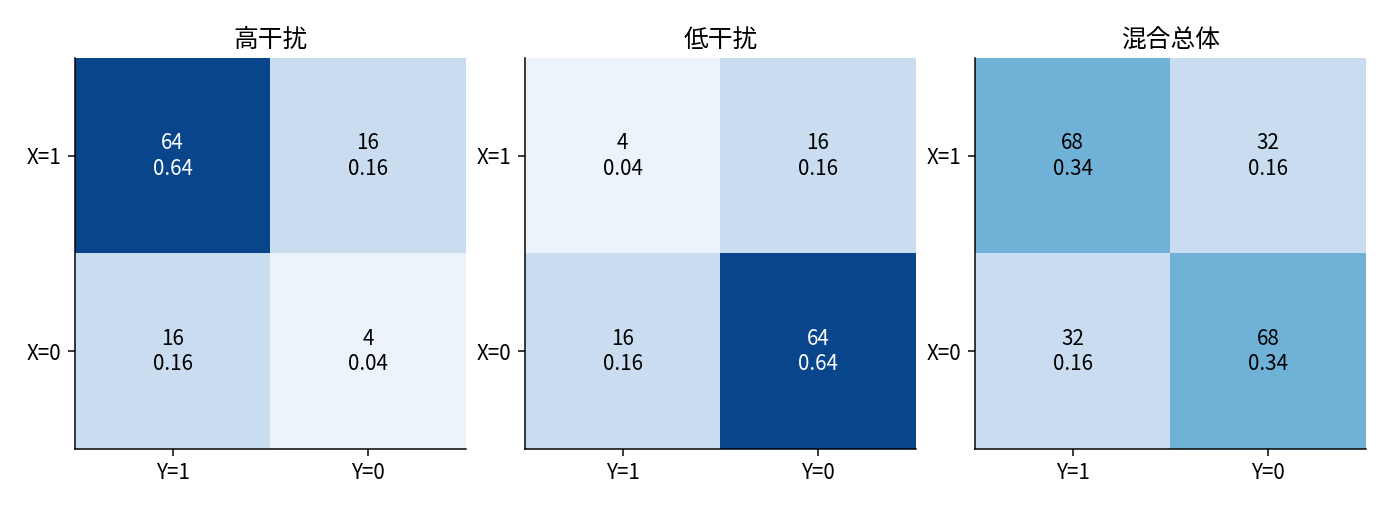

P(H|X=1)= 0.8 P(Y=1|X=1)= 0.68


In [7]:
pooled = groups["high"] + groups["low"]
for name,counts in [("high",groups["high"]),("low",groups["low"]),("pooled",pooled)]:
    print(name,e.independence_report(counts))
fig,axes=plt.subplots(1,3,figsize=(10,3.5),layout="constrained")
for ax,name,counts in zip(axes,["高干扰","低干扰","混合总体"],[groups["high"],groups["low"],pooled]):
    fractions=counts/counts.sum()
    ax.imshow(fractions,cmap="Blues",vmin=0,vmax=.7)
    for (i,j),v in np.ndenumerate(counts):
        ax.text(j,i,f"{v}\n{fractions[i,j]:.2f}",ha="center",va="center",color="white" if fractions[i,j]>.5 else "black")
    ax.set(xticks=[0,1],xticklabels=["Y=1","Y=0"],yticks=[0,1],yticklabels=["X=1","X=0"],title=name)
show_png(fig)
print("P(H|X=1)=",80/100,"P(Y=1|X=1)=",68/100)

## 6 筛选也能制造依赖

四种公平开关组合先各保留一个计数，随后只保留两开关相等的组合。筛选没有修改任何一次开关状态；它改变了样本范围。

In [8]:
before = np.array([[1,1],[1,1]],dtype=int)
after = np.array([[1,0],[0,1]],dtype=int)
print("筛选前:",e.independence_report(before))
print("给定相等:",e.independence_report(after))
e.require(e.independence_report(before)["exact_independence"],"原始例应独立")
e.require(not e.independence_report(after)["exact_independence"],"筛选例应依赖")

筛选前: {'counts': [[1, 1], [1, 1]], 'joint': '1/4', 'product_marginals': '1/4', 'joint_minus_product': '0', 'integer_cross_product_difference': 0, 'exact_independence': True}
给定相等: {'counts': [[1, 0], [0, 1]], 'joint': '1/2', 'product_marginals': '1/4', 'joint_minus_product': '1/4', 'integer_cross_product_difference': 1, 'exact_independence': False}


## 7 零协方差也可能完全可预测

只需三个等权数值对。计算平均xy与平均x乘平均y的差，再用条件事件核验依赖。散点之间的连线只是视觉辅助，不增加新的支持点。

mean x: 0.0 mean y: 0.6666666666666666 covariance: 0.0
P(Y=0)=1/3; P(Y=0|X=0)=1


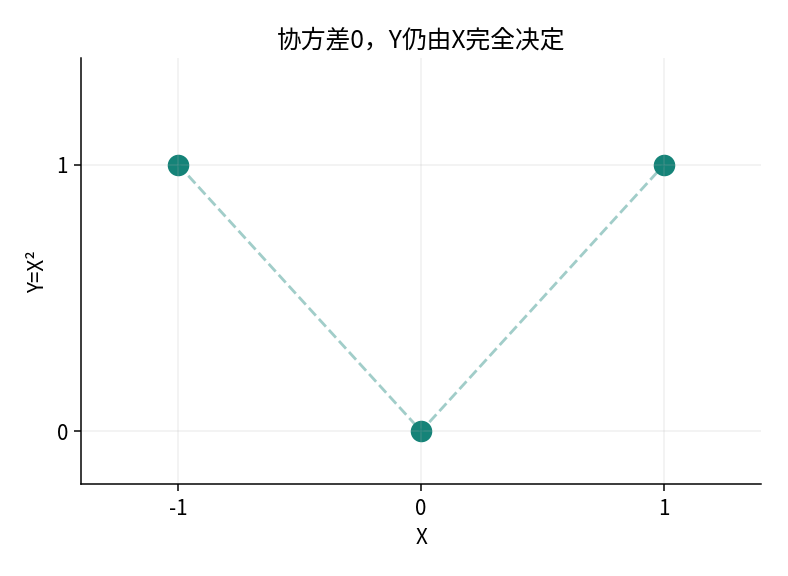

In [9]:
x = np.array([row[0] for row in triples],dtype=float)
y = np.array([row[1] for row in triples],dtype=float)
covariance = float(np.mean(x*y)-np.mean(x)*np.mean(y))
print("mean x:",x.mean(),"mean y:",y.mean(),"covariance:",covariance)
print("P(Y=0)=1/3; P(Y=0|X=0)=1")
e.require(covariance==0,"对称反例协方差应为0")
fig,ax=plt.subplots(figsize=(6.5,4.1))
ax.scatter(x,y,s=110,color=TEAL);ax.plot(x,y,"--",color=TEAL,alpha=.4)
ax.set(xlim=(-1.4,1.4),ylim=(-.2,1.4),xticks=[-1,0,1],yticks=[0,1],xlabel="X",ylabel="Y=X²",title="协方差0，Y仍由X完全决定")
ax.grid(alpha=.2);show_png(fig)

## 8 新样本不必重现固定表的整数

n=100000，种子20261004。模拟先生成缺陷，再按状态生成报警，设备之间独立。固定运行结果应为[[775,201],[4942,94082]]；它只是这个版本和种子的一个样本。

In [10]:
single = e.simulate_devices(n=100000,seed=e.SEED)
print(single)
print("difference from known model:",single["p_defect_given_alarm"]-16/115)
e.require(single["n"]==100000,"计数总和错误")
e.require(single["counts"]==[[775,201],[4942,94082]],"固定版本/种子的参考计数不一致")

{'counts': [[775, 201], [4942, 94082]], 'n': 100000, 'alarm_count': 5717, 'p_defect': 0.00976, 'p_alarm': 0.05717, 'p_alarm_given_defect': 0.7940573770491803, 'p_alarm_given_clean': 0.04990709322992406, 'p_defect_given_alarm': 0.13556060871086234, 'p_defect_given_no_alarm': 0.0021318795541083757}
difference from known model: -0.003569826071746357


## 9 同一模型重复400次

每组输出形状为(400,4)。通过直接四分类计数抽样压缩设备级抽样，避免保留数百万条无用记录。红线为已知真值16/115，橙色阴影是经验2.5%至97.5%范围。中心范围是经验次序统计量，不能叫作真实参数的置信区间。纵轴分别缩放，比较集中程度要看横向宽度。

{'n': 200, 'repeats': 400, 'seed': 20261005, 'valid_runs': 400, 'zero_alarm_runs': 0, 'alarm_count_min': 2, 'alarm_count_median': 12.0, 'alarm_count_max': 23, 'mean_available': 0.14293452077313884, 'q025_available': 0.0, 'q50_available': 0.125, 'q975_available': 0.4, 'interpretation': 'empirical spread across independent runs with positive alarm count; not a confidence interval'}
{'n': 2000, 'repeats': 400, 'seed': 20261006, 'valid_runs': 400, 'zero_alarm_runs': 0, 'alarm_count_min': 82, 'alarm_count_median': 113.0, 'alarm_count_max': 155, 'mean_available': 0.1380540318250917, 'q025_available': 0.07563025210084033, 'q50_available': 0.13636363636363635, 'q975_available': 0.2018348623853211, 'interpretation': 'empirical spread across independent runs with positive alarm count; not a confidence interval'}
{'n': 20000, 'repeats': 400, 'seed': 20261007, 'valid_runs': 400, 'zero_alarm_runs': 0, 'alarm_count_min': 1061, 'alarm_count_median': 1149.0, 'alarm_count_max': 1238, 'mean_available': 

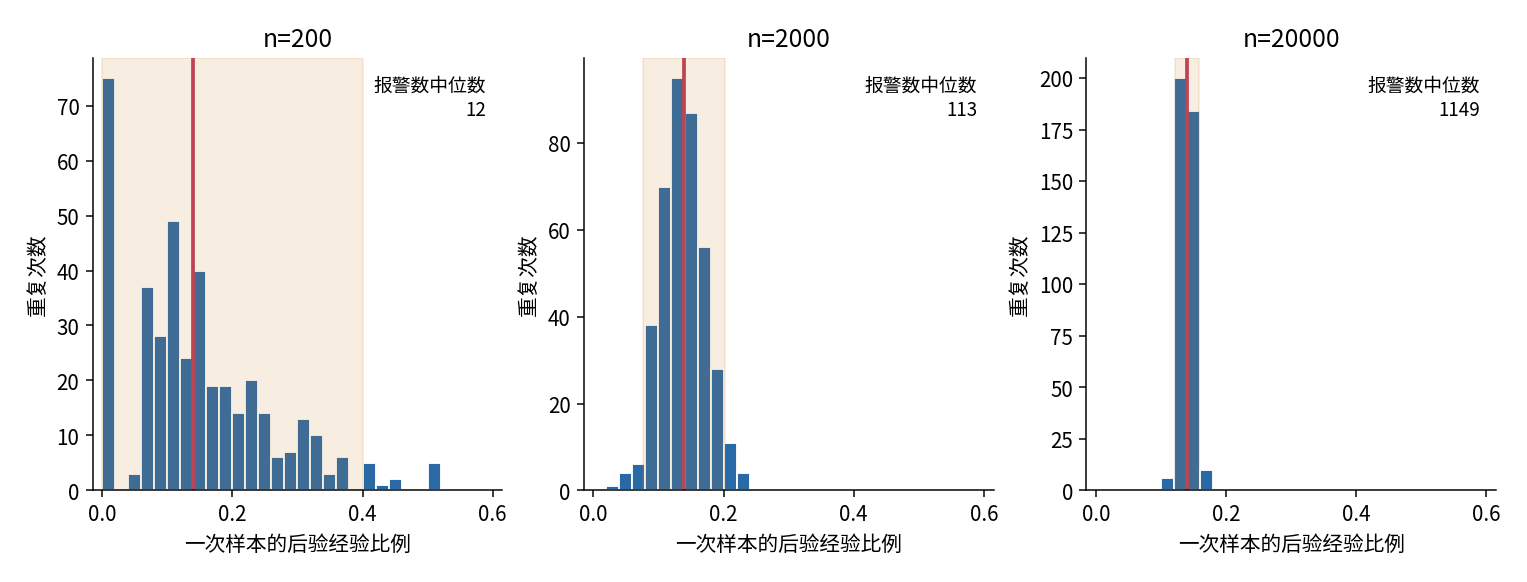

In [11]:
repeats = [e.repeated_simulations(n,400,e.SEED+1+i) for i,n in enumerate([200,2000,20000])]
for result in repeats:
    print(result["summary"])
fig,axes=plt.subplots(1,3,figsize=(11,4),layout="constrained")
for ax,result in zip(axes,repeats):
    summary=result["summary"]
    values=[v for v in result["posterior_estimates"] if v is not None]
    ax.hist(values,bins=np.linspace(0,.6,31),color=BLUE,edgecolor="white")
    ax.axvline(16/115,color=RED,lw=2)
    ax.axvspan(summary["q025_available"],summary["q975_available"],color=ORANGE,alpha=.14)
    ax.set(xlim=(-.015,.615),xlabel="一次样本的后验经验比例",ylabel="重复次数",title=f'n={summary["n"]}')
    ax.text(.96,.96,f'报警数中位数\n{summary["alarm_count_median"]:g}',transform=ax.transAxes,ha="right",va="top",fontsize=10)
show_png(fig)

## 10 未定义不能填0

只抽5台时，主模型仍有正报警概率，但大多数重复恰好没有报警。打印摘要时必须保留无报警次数；对可用比例的分位数只描述可用重复。

In [12]:
rare = e.repeated_simulations(5,400,20261014)
print(rare["summary"])
print("理论无报警概率:",(1-23/400)**5)
e.require(rare["summary"]["zero_alarm_runs"]==296,"固定稀少条件参考不一致")
print("有限表没有报警:",e.summarize_table([[0,5],[0,5]]))
try:
    e.conditional_count(0,0)
except ZeroDivisionError as error:
    print("预期拒绝:",error)
print("模型完全无报警:",e.repeated_simulations(5,10,e.SEED,prior=.1,sensitivity=0,false_alarm=0)["summary"])

{'n': 5, 'repeats': 400, 'seed': 20261014, 'valid_runs': 104, 'zero_alarm_runs': 296, 'alarm_count_min': 0, 'alarm_count_median': 0.0, 'alarm_count_max': 2, 'mean_available': 0.10576923076923077, 'q025_available': 0.0, 'q50_available': 0.0, 'q975_available': 1.0, 'interpretation': 'empirical spread across independent runs with positive alarm count; not a confidence interval'}
理论无报警概率: 0.7437154341461915
有限表没有报警: {'counts': [[0, 5], [0, 5]], 'n': 10, 'alarm_count': 0, 'p_defect': 0.5, 'p_alarm': 0.0, 'p_alarm_given_defect': 0.0, 'p_alarm_given_clean': 0.0, 'p_defect_given_alarm': None, 'p_defect_given_no_alarm': 0.5}
预期拒绝: 条件计数为0，经验条件概率未定义，不能填成0
模型完全无报警: {'n': 5, 'repeats': 10, 'seed': 20261004, 'valid_runs': 0, 'zero_alarm_runs': 10, 'alarm_count_min': 0, 'alarm_count_median': 0.0, 'alarm_count_max': 0, 'mean_available': None, 'q025_available': None, 'q50_available': None, 'q975_available': None, 'interpretation': 'empirical spread across independent runs with positive alarm count; not

## 11 输入和中间算术都要检查

边界报告既包括预期拒绝，也包括合法端点。证据总和的至多1e-12上界舍入超量仅对报告值限幅为1，raw_evidence和修正量另存；后验仍除以实际权重和，全1似然顺序更新不会因一个末位误差失败。数值输入拒绝布尔、字符串、object、非有限值；计数还必须是整数。正乘积下溢或进入次正规范围会保守拒绝。程序没有用户提供的计算回调；所有数值中间量在随机生成前检查。

In [13]:
boundaries=e.boundary_checks()
print("boundary count:",len(boundaries))
for wanted in ["bayes_zero_evidence","bayes_positive_product_underflow","bayes_subnormal_product",
               "no_observed_alarm_returns_none","all_zero_alarm_repeats"]:
    print(next(row for row in boundaries if row["case"]==wanted))
print("整数枚举表数:",e.fraction_checks()["enumerated_integer_tables"])

boundary count: 58
{'case': 'bayes_zero_evidence', 'status': 'rejected_as_expected', 'message': '模型中的证据概率为0，当前离散条件概率未定义'}
{'case': 'bayes_positive_product_underflow', 'status': 'rejected_as_expected', 'message': '正概率乘积下溢为0；请改用精确分数或对数实现'}
{'case': 'bayes_subnormal_product', 'status': 'rejected_as_expected', 'message': '正概率乘积进入次正规范围；本教学实现保守拒绝'}
{'case': 'no_observed_alarm_returns_none', 'status': 'accepted_as_expected'}
{'case': 'all_zero_alarm_repeats', 'status': 'accepted_as_expected'}
整数枚举表数: 80


## 12 最后统一运行并保存

报告保存固定概率、模拟比例、400次重复摘要及全部边界结果。重复CSV中空后验字段是未定义，不是0。重新运行会覆盖本单元的同名可再生成输出。

In [14]:
report=e.run_experiment(write_outputs=True)
e.require(len(report["boundary_checks"])==58,"边界检查数目不符")
print("status: passed; report saved in outputs/")
print("exact posterior:",report["exact_checks"]["posterior_alarm"])
print("single simulated posterior:",report["single_simulation"]["p_defect_given_alarm"])
print("zero-denominator repeats:",report["rare_evidence_summary"]["zero_alarm_runs"])

status: passed; report saved in outputs/
exact posterior: 16/115
single simulated posterior: 0.13556060871086234
zero-denominator repeats: 296


## 小结

检出率80%是在缺陷行内计算；后验16/115是在报警列内计算。基准率不同，相同似然给出的后验也不同。独立、条件独立和零协方差各有不同定义，不能互相代替。有限样本可能没有条件事件，此时比例未定义。

本Notebook已在新Python进程内使用真实ipykernel InProcessKernel顺序执行并保留PNG。构建环境未测试浏览器Jupyter界面、外进程socket传输或学习者本机Anaconda。自己复现时仍应重启内核并运行全部。

来源与模型条件见source-checks.json。官方抽样接口：[NumPy Generator.multinomial](https://numpy.org/doc/2.3/reference/random/generated/numpy.random.Generator.multinomial.html)。正文与answers文档给出一般证明和完整练习解答。